# Papcorns Data Scientist Technical Assessment

**Approach:** All core metrics (Tasks 1–6) are computed via SQL queries executed with `pandas.read_sql`. Python is used only for orchestration, post-processing (e.g. median over a GROUP BY), and visualization. The pLTV bonus (Task 8) is a cohort-based statistical estimate with a brief ML extension.

## 0. Setup

In [9]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

conn = sqlite3.connect("papcorns.sqlite")

def q(sql: str) -> pd.DataFrame:
    """Run a SQL query and return a DataFrame."""
    return pd.read_sql_query(sql, conn)

print("Connected. Tables:", q("SELECT name FROM sqlite_master WHERE type='table'")["name"].tolist())

Connected. Tables: ['users', 'user_events']


### Quick data exploration

In [10]:
print("users (first 5)")
display(q("SELECT * FROM users LIMIT 5"))

print("\nuser_events (first 10)")
display(q("SELECT * FROM user_events LIMIT 10"))

print("\nRow counts")
display(q("""
    SELECT 'users'       AS tbl, COUNT(*) AS rows FROM users
    UNION ALL
    SELECT 'user_events' AS tbl, COUNT(*) AS rows FROM user_events
"""))

print("\nEvent types")
display(q("SELECT event_name, COUNT(*) AS cnt FROM user_events GROUP BY event_name ORDER BY cnt DESC"))

users (first 5)


,id,created_at,attribution_source,country,name
0,1,2024-05-07T00:00:00,instagram,US,Eve Brown
1,2,2024-10-12T00:00:00,instagram,NL,Frank Moore
2,3,2024-10-15T00:00:00,tiktok,TR,Ivy Anderson
3,4,2024-08-28T00:00:00,tiktok,TR,Alice Brown
4,5,2024-04-03T00:00:00,organic,NL,Bob Moore



user_events (first 10)


,id,created_at,user_id,event_name,amount_usd
0,1,2024-05-07T00:00:00,1,app_install,NaN
1,2,2024-05-12T00:00:00,1,trial_started,NaN
2,3,2024-05-24T00:00:00,1,trial_cancelled,NaN
3,4,2024-10-12T00:00:00,2,app_install,NaN
4,5,2024-10-13T00:00:00,2,trial_started,NaN
5,6,2024-10-20T00:00:00,2,subscription_started,8.99
6,7,2024-11-19T00:00:00,2,subscription_renewed,8.99
7,8,2024-12-19T00:00:00,2,subscription_renewed,8.99
8,9,2025-01-18T00:00:00,2,subscription_renewed,8.99
9,10,2025-02-12T00:00:00,2,subscription_cancelled,NaN



Row counts


,tbl,rows
0,users,1002
1,user_events,3486



Event types


,event_name,cnt
0,app_install,1002
1,subscription_renewed,750
2,trial_started,682
3,subscription_started,481
4,subscription_cancelled,370
5,trial_cancelled,201


## Task 1. Total Subscription Revenue by Country

**Definition:** Revenue = `subscription_started` + `subscription_renewed` events (the only rows that carry an `amount_usd`).

,country,total_revenue_usd,paying_users,total_transactions
0,US,4035.96,161,404
1,NL,3335.29,149,371
2,TR,2275.44,171,456


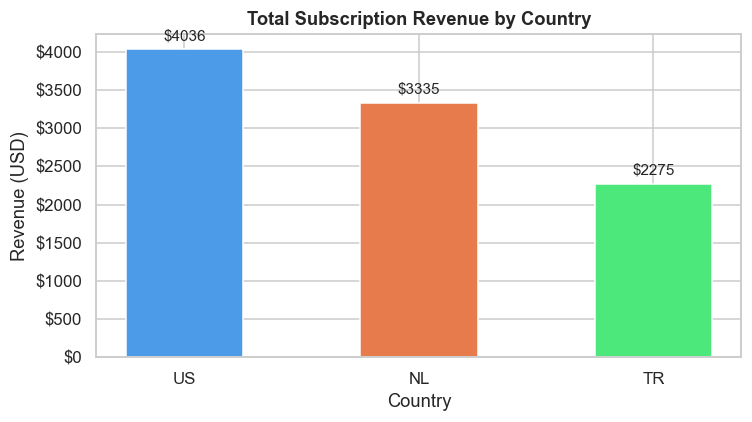

Insight: US leads with $4,035.96 in revenue (41.8% of total $9,646.69) across 161 paying users. TR has the most paying users (171) yet the lowest revenue, indicating a lower price point.


In [11]:
sql_t1 = """
SELECT
    u.country,
    ROUND(SUM(e.amount_usd), 2)      AS total_revenue_usd,
    COUNT(DISTINCT e.user_id)        AS paying_users,
    COUNT(*)                         AS total_transactions
FROM user_events e
JOIN users u ON u.id = e.user_id
WHERE e.event_name IN ('subscription_started', 'subscription_renewed')
GROUP BY u.country
ORDER BY total_revenue_usd DESC
"""

df1 = q(sql_t1)
display(df1)

# Country-to-color map so colors stay consistent across tasks
COUNTRY_COLORS = {"US": "#4C9BE8", "NL": "#E87B4C", "TR": "#4CE87B"}
colors_t1 = [COUNTRY_COLORS[c] for c in df1["country"]]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(df1["country"], df1["total_revenue_usd"], color=colors_t1, width=0.5)
ax.bar_label(bars, fmt="$%.0f", padding=4, fontsize=10)
ax.set_title("Total Subscription Revenue by Country", fontweight="bold")
ax.set_ylabel("Revenue (USD)")
ax.set_xlabel("Country")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("$%.0f"))
plt.tight_layout()
plt.show()

top   = df1.iloc[0]
total = df1["total_revenue_usd"].sum()
print(
    f"Insight: {top['country']} leads with ${top['total_revenue_usd']:,.2f} in revenue "
    f"({top['total_revenue_usd']/total*100:.1f}% of total ${total:,.2f}) "
    f"across {top['paying_users']} paying users. "
    f"TR has the most paying users ({df1[df1['country']=='TR']['paying_users'].values[0]}) "
    f"yet the lowest revenue, indicating a lower price point."
)

## Task 2. Total Trials from Instagram Users

**Definition:** Count `trial_started` events for users whose `attribution_source = 'instagram'`.

In [12]:
sql_t2 = """
SELECT
    COUNT(*)                  AS total_trials_instagram,
    COUNT(DISTINCT e.user_id) AS unique_users_trialed
FROM user_events e
JOIN users u ON u.id = e.user_id
WHERE u.attribution_source = 'instagram'
  AND e.event_name = 'trial_started'
"""

df2 = q(sql_t2)
display(df2)

trials = int(df2.iloc[0]["total_trials_instagram"])
users  = int(df2.iloc[0]["unique_users_trialed"])
print(
    f"Insight: Instagram drove {trials} trials from {users} unique users. "
    f"The 1:1 ratio (trials == unique users) confirms each Instagram user "
    f"started at most one trial, no duplicate trial events for this channel."
)

,total_trials_instagram,unique_users_trialed
0,210,210


Insight: Instagram drove 210 trials from 210 unique users. The 1:1 ratio (trials == unique users) confirms each Instagram user started at most one trial, no duplicate trial events for this channel.
